In [1]:
#  This code is used just to create the skew-T plot of global, annual mean air temperature
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr
from metpy.plots import SkewT
import climlab

#plt.style.use('dark_background')

#  This code is used just to create the skew-T plot of global, annual mean air temperature
#ncep_url = "http://www.esrl.noaa.gov/psd/thredds/dodsC/Datasets/ncep.reanalysis.derived/"
ncep_url = "/Users/yuchiaol_ntuas/Desktop/ebooks/data/"
#time_coder = xr.coders.CFDatetimeCoder(use_cftime=True)
ncep_air = xr.open_dataset( ncep_url + "air.mon.1981-2010.ltm.nc", use_cftime=True)
#  Take global, annual average 
coslat = np.cos(np.deg2rad(ncep_air.lat))
weight = coslat / coslat.mean(dim='lat')
Tglobal = (ncep_air.air * weight).mean(dim=('lat','lon','time'))

print(Tglobal)

#  Resuable function to plot the temperature data on a Skew-T chart
def make_skewT():
    fig = plt.figure(figsize=(9, 9))
    skew = SkewT(fig, rotation=30)
    skew.plot(Tglobal.level, Tglobal, color='black', linestyle='-', linewidth=2, label='Observations')
    skew.ax.set_ylim(1050, 10)
    skew.ax.set_xlim(-90, 45)
    # Add the relevant special lines
    skew.plot_dry_adiabats(linewidth=0.5)
    skew.plot_moist_adiabats(linewidth=0.5)
    #skew.plot_mixing_lines()
    skew.ax.legend()
    skew.ax.set_xlabel('Temperature (degC)', fontsize=14)
    skew.ax.set_ylabel('Pressure (hPa)', fontsize=14)
    return skew

#  and a function to add extra profiles to this chart
def add_profile(skew, model, linestyle='-', color=None):
    line = skew.plot(model.lev, model.Tatm - climlab.constants.tempCtoK,
             label=model.name, linewidth=2)[0]
    skew.plot(1000, model.Ts - climlab.constants.tempCtoK, 'o', 
              markersize=8, color=line.get_color())
    skew.ax.legend()


<xarray.DataArray (level: 17)> Size: 68B
array([ 15.179084  ,  11.207003  ,   7.8383274 ,   0.21994135,
        -6.4483433 , -14.888848  , -25.570469  , -39.36969   ,
       -46.797905  , -53.652245  , -60.56356   , -67.006065  ,
       -65.53293   , -61.48664   , -55.853584  , -51.593952  ,
       -43.21999   ], dtype=float32)
Coordinates:
  * level    (level) float32 68B 1e+03 925.0 850.0 700.0 ... 50.0 30.0 20.0 10.0


In [2]:
# Get the water vapor data from CESM output
#cesm_data_path = "http://thredds.atmos.albany.edu:8080/thredds/dodsC/CESMA/"
cesm_data_path = "/Users/yuchiaol_ntuas/Desktop/ebooks/data/"
atm_control = xr.open_dataset(cesm_data_path + "cpl_1850_f19.cam.h0.nc")
# Take global, annual average of the specific humidity
weight_factor = atm_control.gw / atm_control.gw.mean(dim='lat')
Qglobal = (atm_control.Q * weight_factor).mean(dim=('lat','lon','time'))

#  Make a model on same vertical domain as the GCM
mystate = climlab.column_state(lev=Qglobal.lev, water_depth=2.5)
#  Build the radiation model -- just like we already did
rad = climlab.radiation.RRTMG(name='Radiation',
                              state=mystate, 
                              specific_humidity=Qglobal.values,
                              timestep = climlab.constants.seconds_per_day,
                              albedo = 0.25,  # surface albedo, tuned to give reasonable ASR for reference cloud-free model
                             )
#  Now create the convection model
conv = climlab.convection.ConvectiveAdjustment(name='Convection',
                                               state=mystate,
                                               adj_lapse_rate=6.5,
                                               timestep=rad.timestep,
                                              )
#  Here is where we build the model by coupling together the two components
rcm = climlab.couple([rad, conv], name='Radiative-Convective Model')

print(rcm)

print(rcm.subprocess['Radiation'].absorber_vmr['CO2'])

print(rcm.integrate_years(5))

print(rcm.ASR - rcm.OLR)


climlab Process of type <class 'climlab.process.time_dependent_process.TimeDependentProcess'>. 
State variables and domain shapes: 
  Ts: (1,) 
  Tatm: (26,) 
The subprocess tree: 
Radiative-Convective Model: <class 'climlab.process.time_dependent_process.TimeDependentProcess'>
   Radiation: <class 'climlab.radiation.rrtm.rrtmg.RRTMG'>
      SW: <class 'climlab.radiation.rrtm.rrtmg_sw.RRTMG_SW'>
      LW: <class 'climlab.radiation.rrtm.rrtmg_lw.RRTMG_LW'>
   Convection: <class 'climlab.convection.convadj.ConvectiveAdjustment'>

0.000348
Integrating for 1826 steps, 1826.2110000000002 days, or 5 years.


Total elapsed time is 4.999422301147019 years.
None
[-3.3651304e-11]


In [3]:
# Make an exact clone with same temperatures
rcm_2xCO2 = climlab.process_like(rcm)
rcm_2xCO2.name = 'Radiative-Convective Model (2xCO2 initial)'

#  Check to see that we indeed have the same CO2 amount
print(rcm_2xCO2.subprocess['Radiation'].absorber_vmr['CO2'])

#  Now double it!
rcm_2xCO2.subprocess['Radiation'].absorber_vmr['CO2'] *= 2

print(rcm_2xCO2.subprocess['Radiation'].absorber_vmr['CO2'])


0.000348
0.000696


In [4]:
rcm_2xCO2.compute_diagnostics()

print(rcm_2xCO2.ASR - rcm.ASR)

print(rcm_2xCO2.OLR - rcm.OLR)

DeltaR_instant = (rcm_2xCO2.ASR - rcm_2xCO2.OLR) - (rcm.ASR - rcm.OLR)

print(DeltaR_instant)


[0.06274162]
[-2.11458541]
[2.17732704]


In [5]:
# print out troposphere
print(rcm.lev[13:])

rcm_2xCO2_strat = climlab.process_like(rcm_2xCO2)
rcm_2xCO2_strat.name = 'Radiative-Convective Model (2xCO2 stratosphere-adjusted)'
for n in range(1000):
    rcm_2xCO2_strat.step_forward()
# hold tropospheric and surface temperatures fixed
    rcm_2xCO2_strat.Tatm[13:] = rcm.Tatm[13:]
    rcm_2xCO2_strat.Ts[:] = rcm.Ts[:]

DeltaR = (rcm_2xCO2_strat.ASR - rcm_2xCO2_strat.OLR) - (rcm.ASR - rcm.OLR)
print(DeltaR)


[226.513265 266.481155 313.501265 368.81798  433.895225 510.455255
 600.5242   696.79629  787.70206  867.16076  929.648875 970.55483
 992.5561  ]


[4.28837377]


In [6]:
OLRobserved = 238.5  # in W/m2
sigma = 5.67E-8  # S-B constant
Tsobserved = 288.  # global average surface temperature
tau = OLRobserved / sigma / Tsobserved**4  # solve for tuned value of transmissivity

lambda_0 = 4 * sigma * tau * Tsobserved**3

DeltaR_test = 4.  # Radiative forcing in W/m2
DeltaT0 = DeltaR_test / lambda_0
print( 'The Equilibrium Climate Sensitivity in the absence of feedback is {:.1f} K.'.format(DeltaT0))

The Equilibrium Climate Sensitivity in the absence of feedback is 1.2 K.


Integrating for 1826 steps, 1826.2110000000002 days, or 5 years.


Total elapsed time is 12.736753858124827 years.
rcm_2xCO2_eq.ASR - rcm_2xCO2_eq.OLR
[1.31308298e-11]
ECS with no feedback
[1.29984831]
rcm_2xCO2_eq.OLR - rcm.OLR
[0.05080282]
rcm_2xCO2_eq.ASR - rcm.ASR
[0.05080282]
lambda0
[3.29913401]


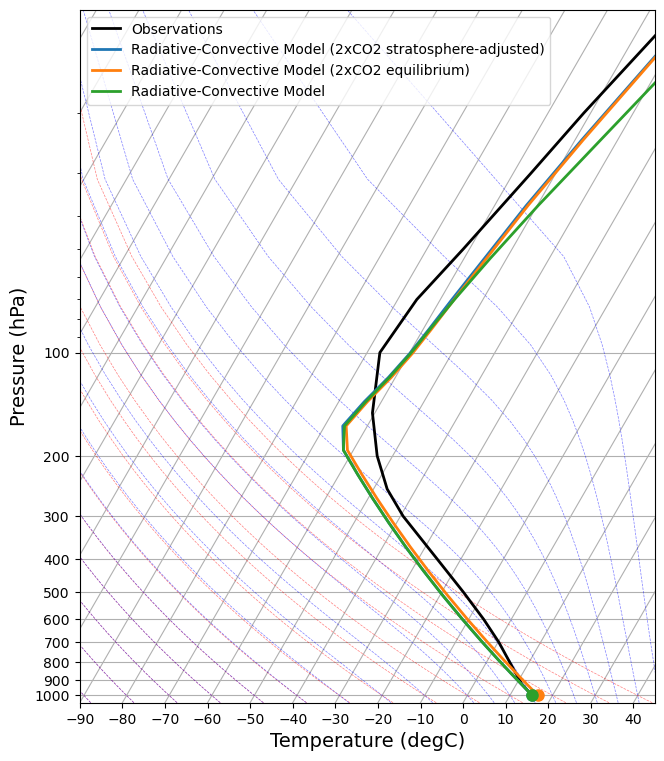

In [7]:
rcm_2xCO2_eq = climlab.process_like(rcm_2xCO2_strat)
rcm_2xCO2_eq.name = 'Radiative-Convective Model (2xCO2 equilibrium)'
rcm_2xCO2_eq.integrate_years(5)

print('rcm_2xCO2_eq.ASR - rcm_2xCO2_eq.OLR')
print(rcm_2xCO2_eq.ASR - rcm_2xCO2_eq.OLR)

skew = make_skewT()
add_profile(skew, rcm_2xCO2_strat)
add_profile(skew, rcm_2xCO2_eq)
add_profile(skew, rcm)

ECS_nofeedback = rcm_2xCO2_eq.Ts - rcm.Ts
print('ECS with no feedback')
print(ECS_nofeedback)

print('rcm_2xCO2_eq.OLR - rcm.OLR')
print(rcm_2xCO2_eq.OLR - rcm.OLR)
print('rcm_2xCO2_eq.ASR - rcm.ASR')
print(rcm_2xCO2_eq.ASR - rcm.ASR)

lambda0 = DeltaR / ECS_nofeedback
print('lambda0')
print(lambda0)


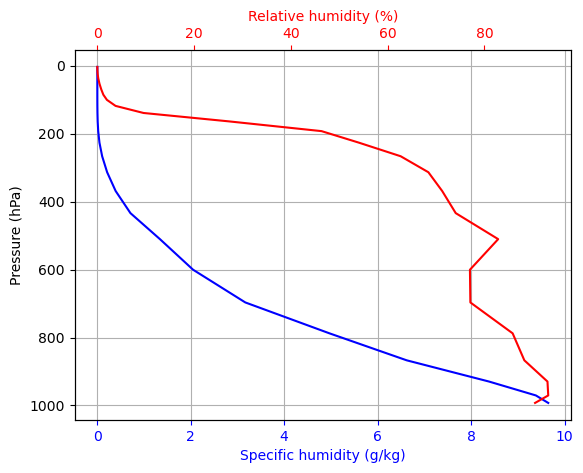

In [8]:
#  actual specific humidity
q = rcm.subprocess['Radiation'].specific_humidity
#  saturation specific humidity (a function of temperature and pressure)
qsat = climlab.utils.thermo.qsat(rcm.Tatm, rcm.lev)
#  Relative humidity
rh = q/qsat

#  Plot relative humidity in percent
fig,ax = plt.subplots()
ax.plot(q*1000, rcm.lev, 'b-')
ax.invert_yaxis()
ax.grid()
ax.set_ylabel('Pressure (hPa)')
ax.set_xlabel('Specific humidity (g/kg)', color='b')
ax.tick_params('x', colors='b')
ax2 = ax.twiny()
ax2.plot(rh*100., rcm.lev, 'r-')
ax2.set_xlabel('Relative humidity (%)', color='r')
ax2.tick_params('x', colors='r')


[-1.73180638e-07]


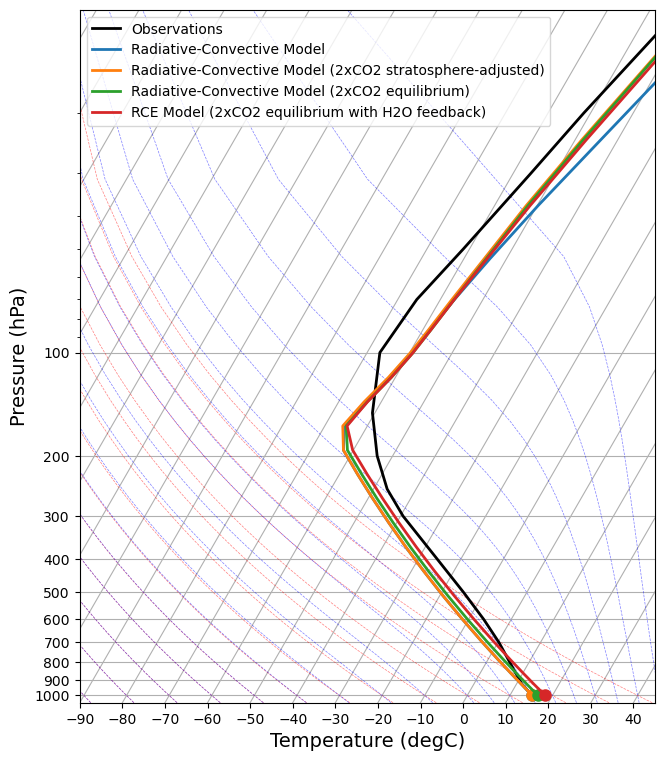

In [9]:
rcm_2xCO2_h2o = climlab.process_like(rcm_2xCO2)
rcm_2xCO2_h2o.name = 'RCE Model (2xCO2 equilibrium with H2O feedback)'

for n in range(2000):
    # At every timestep
    # we calculate the new saturation specific humidity for the new temperature
    #  and change the water vapor in the radiation model
    #  so that relative humidity is always the same
    qsat = climlab.utils.thermo.qsat(rcm_2xCO2_h2o.Tatm, rcm_2xCO2_h2o.lev)
    rcm_2xCO2_h2o.subprocess['Radiation'].specific_humidity[:] = rh * qsat
    rcm_2xCO2_h2o.step_forward()

# Check for energy balance
print(rcm_2xCO2_h2o.ASR - rcm_2xCO2_h2o.OLR)

skew = make_skewT()
add_profile(skew, rcm)
add_profile(skew, rcm_2xCO2_strat)
add_profile(skew, rcm_2xCO2_eq)
add_profile(skew, rcm_2xCO2_h2o)


In [10]:
ECS = rcm_2xCO2_h2o.Ts - rcm.Ts
print('ECS')
print(ECS)

g = ECS / ECS_nofeedback
print('gain')
print(g)

lambda_net = DeltaR / ECS
print('lambda_net')
print(lambda_net)

print('lambda0')
print(lambda0)

lambda_h2o = lambda0 - lambda_net
print('lambda_h2o')
print(lambda_h2o)


ECS
[2.98902357]
gain
[2.29951722]
lambda_net
[1.43470724]
lambda0
[3.29913401]
lambda_h2o
[1.86442677]


In [11]:
startingamount = 1.
amount = startingamount
for n in range(70):
    amount *= 1.01
print(amount)

2.006763368395386


In [12]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr

casenames = {'cpl_control': 'cpl_1850_f19',
             'cpl_CO2ramp': 'cpl_CO2ramp_f19',
             'som_control': 'som_1850_f19',
             'som_2xCO2':   'som_1850_2xCO2',
            }
# The path to the THREDDS server, should work from anywhere
basepath = '~/Desktop/ebooks/data/'
# For better performance if you can access the roselab_rit filesystem (e.g. from JupyterHub)
# basepath = '/roselab_rit/cesm_archive/'
casepaths = {}
for name in casenames:
    casepaths[name] = basepath

# make a dictionary of all the CAM atmosphere output
atm = {}
for name in casenames:
    path = casepaths[name] + casenames[name] + '.cam.h0.nc'
    print('Attempting to open the dataset ', path)
    atm[name] = xr.open_dataset(path, decode_times=False)


Attempting to open the dataset  ~/Desktop/ebooks/data/cpl_1850_f19.cam.h0.nc


Attempting to open the dataset  ~/Desktop/ebooks/data/cpl_CO2ramp_f19.cam.h0.nc
Attempting to open the dataset  ~/Desktop/ebooks/data/som_1850_f19.cam.h0.nc
Attempting to open the dataset  ~/Desktop/ebooks/data/som_1850_2xCO2.cam.h0.nc


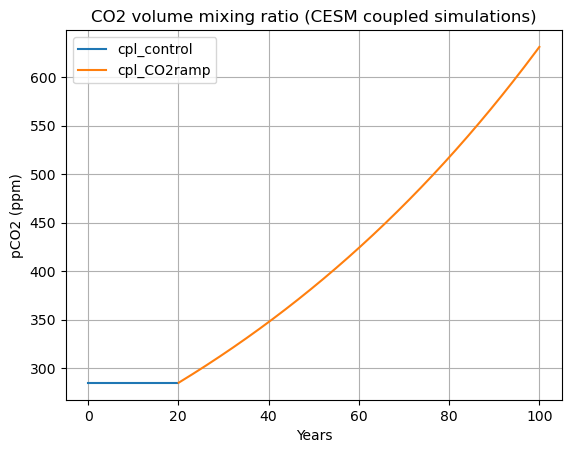

In [13]:
days_per_year = 365
fig, ax = plt.subplots()
for name in ['cpl_control', 'cpl_CO2ramp']:
    ax.plot(atm[name].time/days_per_year, atm[name].co2vmr*1E6, label=name)
ax.set_title('CO2 volume mixing ratio (CESM coupled simulations)')
ax.set_xlabel('Years')
ax.set_ylabel('pCO2 (ppm)')
ax.grid()
ax.legend();

<xarray.DataArray 'TREFHT' (time: 240, lat: 96, lon: 144)> Size: 13MB
[3317760 values with dtype=float32]
Coordinates:
  * time     (time) float64 2kB 31.0 59.0 90.0 ... 7.239e+03 7.269e+03 7.3e+03
  * lat      (lat) float64 768B -90.0 -88.11 -86.21 -84.32 ... 86.21 88.11 90.0
  * lon      (lon) float64 1kB 0.0 2.5 5.0 7.5 10.0 ... 350.0 352.5 355.0 357.5
Attributes:
    units:         K
    long_name:     Reference height temperature
    cell_methods:  time: mean
<xarray.DataArray 'gw' (lat: 96)> Size: 768B
[96 values with dtype=float64]
Coordinates:
  * lat      (lat) float64 768B -90.0 -88.11 -86.21 -84.32 ... 86.21 88.11 90.0
Attributes:
    long_name:  gauss weights


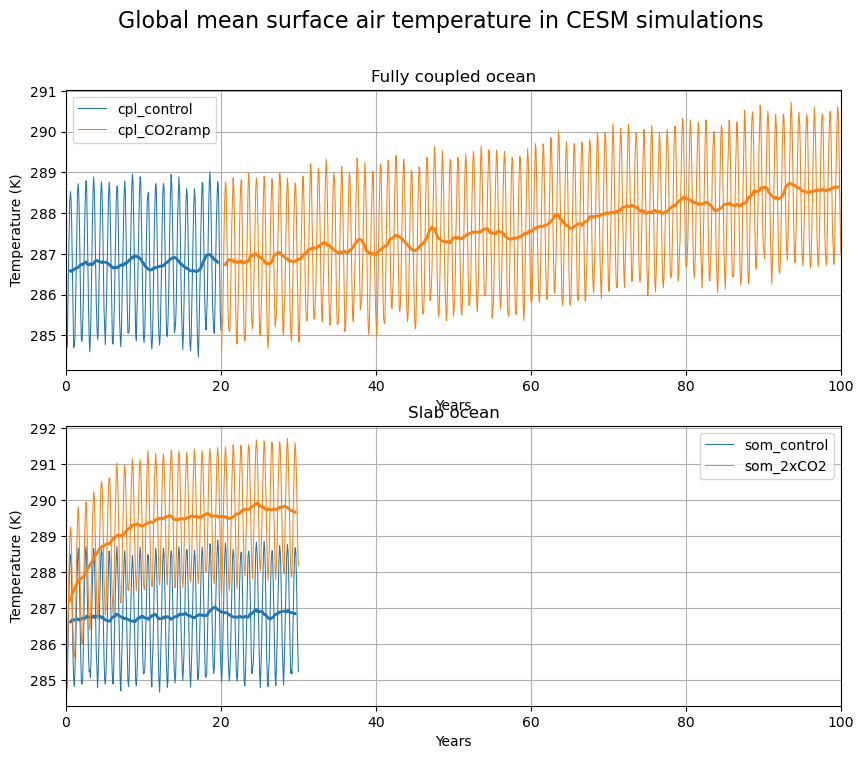

In [14]:
print(atm['cpl_control'].TREFHT)

#  The area weighting needed for global averaging
gw = atm['som_control'].gw
print(gw)

def global_mean(field, weight=gw):
    '''Return the area-weighted global average of the input field'''
    return (field*weight).mean(dim=('lat','lon'))/weight.mean(dim='lat')

#  Loop through the four simulations and produce the global mean timeseries
TREFHT_global = {}
for name in casenames:
    TREFHT_global[name] = global_mean(atm[name].TREFHT)

fig, axes = plt.subplots(2,1,figsize=(10,8))
for name in casenames:
    if 'cpl' in name:
        ax = axes[0]
        ax.set_title('Fully coupled ocean')
    else:
        ax = axes[1]
        ax.set_title('Slab ocean')
    field = TREFHT_global[name]
    field_running = field.rolling(time=12, center=True).mean()
    line = ax.plot(field.time / days_per_year, 
                   field, 
                   label=name,
                   linewidth=0.75,
                   )
    ax.plot(field_running.time / days_per_year, 
            field_running, 
            color=line[0].get_color(),
            linewidth=2,
           )
for ax in axes:
    ax.legend();
    ax.set_xlabel('Years')
    ax.set_ylabel('Temperature (K)')
    ax.grid();
    ax.set_xlim(0,100)

fig.suptitle('Global mean surface air temperature in CESM simulations', fontsize=16);



In [15]:
# extract the last 10 years from the slab ocean control simulation
# and the last 20 years from the coupled control
nyears_slab = 10
nyears_cpl = 20
clim_slice_slab = slice(-(nyears_slab*12),None)
clim_slice_cpl = slice(-(nyears_cpl*12),None)

# extract the last 10 years from the slab ocean control simulation
T0_slab = TREFHT_global['som_control'].isel(time=clim_slice_slab).mean(dim='time')
print(T0_slab)

# and the last 20 years from the coupled control
T0_cpl = TREFHT_global['cpl_control'].isel(time=clim_slice_cpl).mean(dim='time')
print(T0_cpl)

# extract the last 10 years from the slab 2xCO2 simulation
T2x_slab = TREFHT_global['som_2xCO2'].isel(time=clim_slice_slab).mean(dim='time')
print(T2x_slab)

# extract the last 20 years from the coupled CO2 ramp simulation
T2x_cpl = TREFHT_global['cpl_CO2ramp'].isel(time=clim_slice_cpl).mean(dim='time')
print(T2x_cpl)

ECS = T2x_slab - T0_slab
TCR = T2x_cpl - T0_cpl
print('The Equilibrium Climate Sensitivity is {:.3} K.'.format(float(ECS)))
print('The Transient Climate Response is {:.3} K.'.format(float(TCR)))



<xarray.DataArray ()> Size: 8B
array(286.82486457)
<xarray.DataArray ()> Size: 8B
array(286.75125938)
<xarray.DataArray ()> Size: 8B
array(289.71521445)
<xarray.DataArray ()> Size: 8B
array(288.41935278)
The Equilibrium Climate Sensitivity is 2.89 K.
The Transient Climate Response is 1.67 K.


(0.0, 7.0)

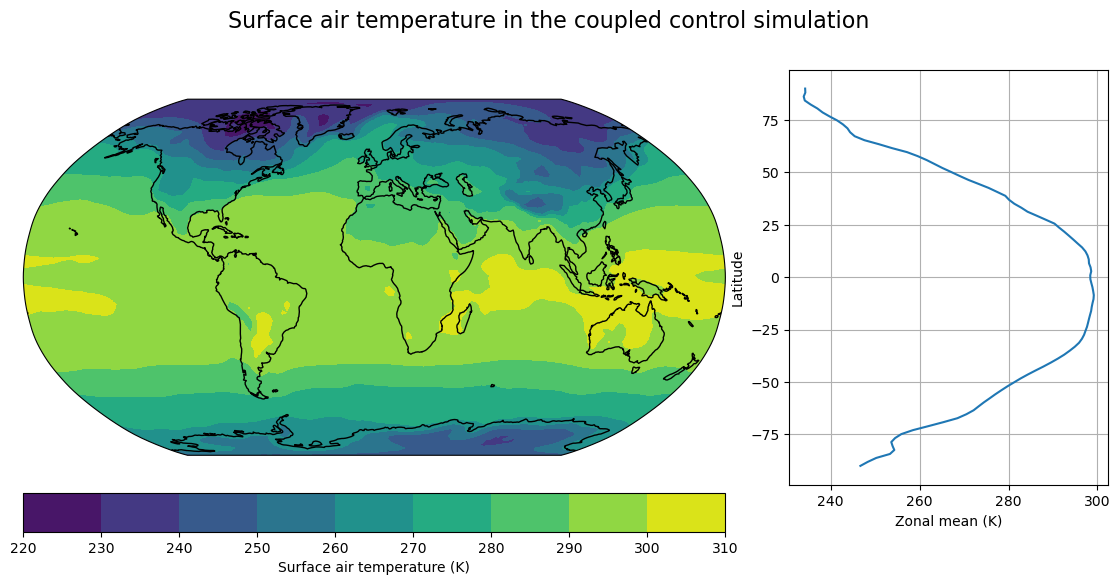

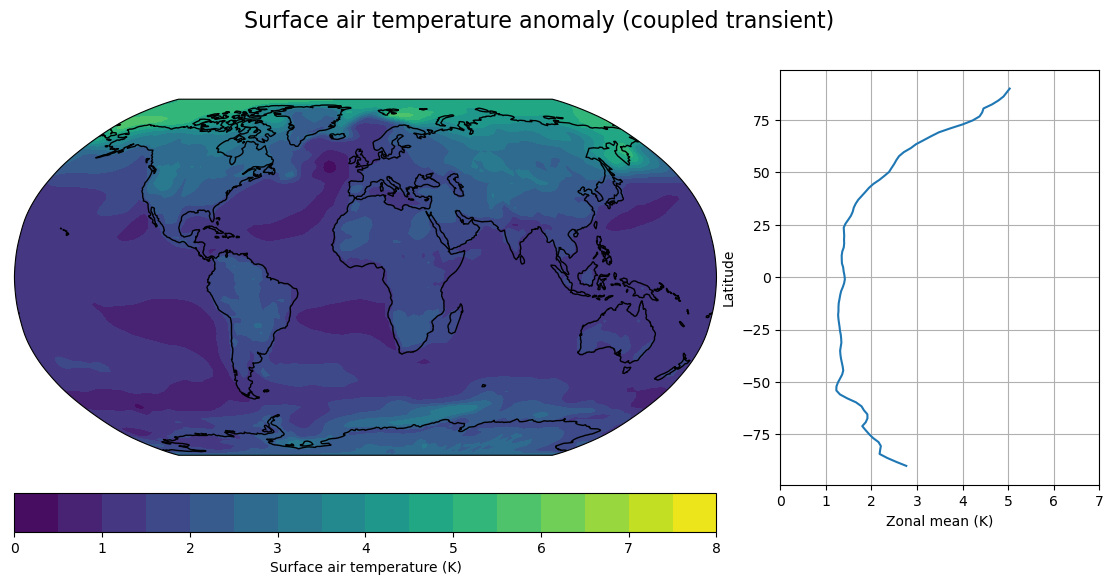

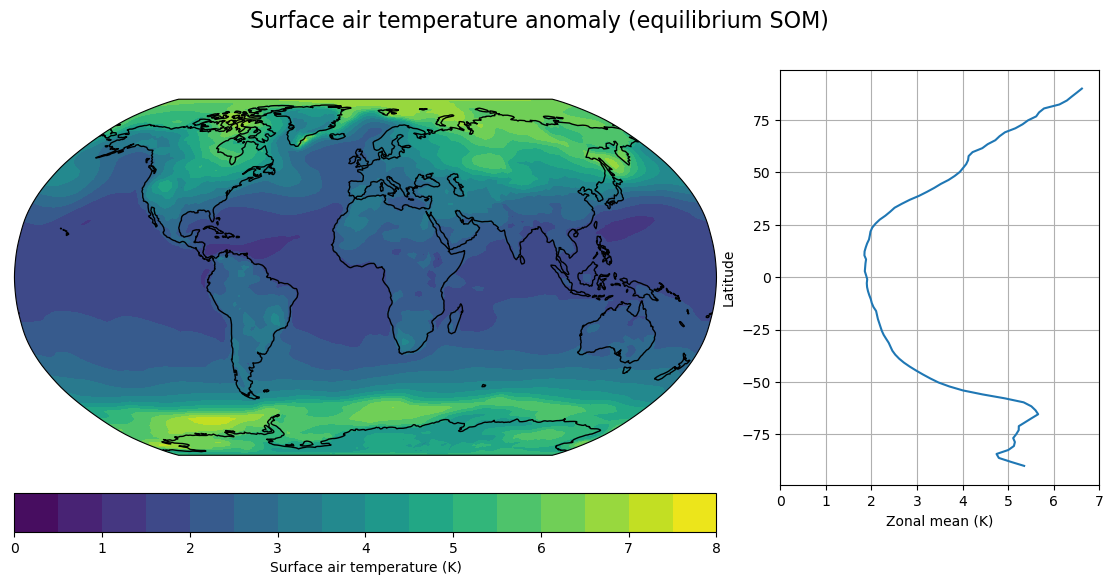

In [16]:
# The map projection capabilities come from the cartopy package. There are many possible projections
import cartopy.crs as ccrs
from cartopy.util import add_cyclic_point

def make_map(field, title="", levels=8):
    '''input field should be a 2D xarray.DataArray on a lat/lon grid.
        Make a filled contour plot of the field, and a line plot of the zonal mean
    '''
    fig = plt.figure(figsize=(14,6))
    nrows = 10; ncols = 3
    mapax = plt.subplot2grid((nrows,ncols), (0,0), colspan=ncols-1, rowspan=nrows-1, projection=ccrs.Robinson())
    barax = plt.subplot2grid((nrows,ncols), (nrows-1,0), colspan=ncols-1)
    plotax = plt.subplot2grid((nrows,ncols), (0,ncols-1), rowspan=nrows-1)
    # add cyclic point so cartopy doesn't show a white strip at zero longitude
    wrap_data, wrap_lon = add_cyclic_point(field.values, coord=field.lon, axis=field.dims.index('lon'))
    cx = mapax.contourf(wrap_lon, field.lat, wrap_data, levels=levels, transform=ccrs.PlateCarree())
    mapax.set_global(); mapax.coastlines();
    plt.colorbar(cx, cax=barax, orientation='horizontal', label='Surface air temperature (K)')
    plotax.plot(field.mean(dim='lon'), field.lat)
    plotax.set_xlabel('Zonal mean (K)')
    plotax.set_ylabel('Latitude')
    plotax.grid()
    fig.suptitle(title, fontsize=16)
    return fig, (mapax, plotax, barax), cx

# Plot a single time slice of surface air temperature just as example
fig, axes, cx = make_map(atm['cpl_control'].TREFHT.isel(time=0), 
                        title="Surface air temperature in the coupled control simulation")

Tmap_cpl_2x = atm['cpl_CO2ramp'].TREFHT.isel(time=clim_slice_cpl).mean(dim='time')
Tmap_cpl_control = atm['cpl_control'].TREFHT.isel(time=clim_slice_cpl).mean(dim='time')
DeltaT_cpl = Tmap_cpl_2x - Tmap_cpl_control

Tmap_som_2x = atm['som_2xCO2'].TREFHT.isel(time=clim_slice_slab).mean(dim='time')
Tmap_som_control = atm['som_control'].TREFHT.isel(time=clim_slice_slab).mean(dim='time')
DeltaT_som = Tmap_som_2x - Tmap_som_control


contours = np.arange(0., 8.5, 0.5)
fig, axes, cx = make_map(DeltaT_cpl, levels=contours,
                        title="Surface air temperature anomaly (coupled transient)")
axes[1].set_xlim(0,7)  # ensure the line plots have same axes

fig, axes,cx  = make_map(DeltaT_som, levels=contours,
                         title="Surface air temperature anomaly (equilibrium SOM)")
axes[1].set_xlim(0,7)


In [17]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr
import climlab

# Get the water vapor data from CESM output
cesm_data_path = "~/Desktop/ebooks/data/"
atm_control = xr.open_dataset(cesm_data_path + "cpl_1850_f19.cam.h0.nc")
# Take global, annual average of the specific humidity
weight_factor = atm_control.gw / atm_control.gw.mean(dim='lat')
Qglobal = (atm_control.Q * weight_factor).mean(dim=('lat','lon','time'))

#  Make a model on same vertical domain as the GCM
state = climlab.column_state(lev=Qglobal.lev, water_depth=2.5)
steps_per_year = 90
deltat = climlab.constants.seconds_per_year/steps_per_year
rad = climlab.radiation.RRTMG(name='Radiation',
                              state=state, 
                              specific_humidity=Qglobal.values,
                              timestep = deltat,
                              albedo = 0.25,  # tuned to give reasonable ASR for reference cloud-free model
                             )
conv = climlab.convection.ConvectiveAdjustment(name='Convection',
                                               state=state,
                                               adj_lapse_rate=6.5,
                                               timestep=rad.timestep,)
rcm_control = climlab.couple([rad,conv], name='Radiative-Convective Model')

rcm_control.integrate_years(5)
rcm_control.ASR - rcm_control.OLR

slab_control = []
slab_control.append(rcm_control)
slab_control.append(climlab.process_like(rcm_control))

slab_2x = []
for n in range(len(slab_control)):
    rcm_2xCO2 = climlab.process_like(rcm_control)
    rcm_2xCO2.subprocess['Radiation'].absorber_vmr['CO2'] *= 2.
    if n == 0:
        rcm_2xCO2.name = 'High-sensitivity RCM'
    elif n == 1:
        rcm_2xCO2.name = 'Low-sensitivity RCM'
    slab_2x.append(rcm_2xCO2)

#  actual specific humidity
q = rcm_control.subprocess['Radiation'].specific_humidity
#  saturation specific humidity (a function of temperature and pressure)
qsat = climlab.utils.thermo.qsat(rcm_control.Tatm, rcm_control.lev)
#  Relative humidity (stay fixed!)
rh = q/qsat


Integrating for 450 steps, 1826.2110000000002 days, or 5 years.


Total elapsed time is 5.000000000000044 years.
